## Greedy feature selection

In [25]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('penguins_size.csv')
df.loc[df['sex']=='.'.index, 'sex'] = np.nan

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.dropna(thresh=3, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [8]:
X = df.drop('species', axis=1)
y = df['species']

# 欠損値代入
imputer = SimpleImputer(strategy='constant', fill_value='NaN')
imputer.set_output(transform='pandas')
X['sex'] = imputer.fit_transform(X[['sex']])

# ダミー変数生成クラスを自作（Pipelineに組み込むため）
class GetDummies(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.columns = None
        
    def fit(self, X, y=None):
        self.columns = pd.get_dummies(X).columns
        return self
    
    def transform(self, X):
        X_new = pd.get_dummies(X)
        return X_new.reindex(columns=self.columns, fill_value=0)
    
# 特徴量エンジニアリング
# 多項式特徴量
poly = PolynomialFeatures(degree=2, include_bias=False)
X[['culmen_length_mm', 'culmen_depth_mm','culmen_length_mm^2', 'culmen_depth_mm^2', 'culmen_length_mm * culmen_depth_mm']] = poly.fit_transform(X[['culmen_length_mm', 'culmen_depth_mm']])

# 四則演算
X['culmen_diff'] = X['culmen_length_mm'] - X['culmen_depth_mm']
X['culmen_ratio'] = X['culmen_length_mm'] / X['culmen_depth_mm']

# Pipeline
pipeline = Pipeline([('dummy', GetDummies()),
         ('scaler', StandardScaler()),
         ('model', LogisticRegression())
         ])

# CV
cv = KFold(n_splits=3, random_state=0, shuffle=True)

# Greedy feature selection
gfs = GreedyFeatureSelection(pipeline=pipeline, cv=cv)
gfs.select_features(X, y)

greedy selection started
['island'] score: 0.7076023391812866
best score updated 0 -> 0.7076023391812866
['culmen_length_mm'] score: 0.7514619883040936
best score updated 0.7076023391812866 -> 0.7514619883040936
['culmen_depth_mm'] score: 0.7573099415204679
best score updated 0.7514619883040936 -> 0.7573099415204679
['flipper_length_mm'] score: 0.7982456140350876
best score updated 0.7573099415204679 -> 0.7982456140350876
['body_mass_g'] score: 0.7309941520467835
['sex'] score: 0.3976608187134503
['culmen_length_mm^2'] score: 0.7543859649122808
['culmen_depth_mm^2'] score: 0.5350877192982456
['culmen_length_mm * culmen_depth_mm'] score: 0.7573099415204679
['culmen_diff'] score: 0.8187134502923977
best score updated 0.7982456140350876 -> 0.8187134502923977
['culmen_ratio'] score: 0.9619883040935672
best score updated 0.8187134502923977 -> 0.9619883040935672
===============culmen_ratio===============
greedy selection started
['culmen_ratio', 'island'] score: 0.9912280701754387
best score

In [7]:
class  GreedyFeatureSelection():
    
    def __init__(self, pipeline, cv):
        self.pipeline = pipeline
        self.cv = cv
        self.selected_features = []
        self.scores = [0]
        
    def select_features(self, X, y):
        
        all_features = X.columns
        while True:
            print('greedy selection started')
            best_score = self.scores[-1]
            candidate_feature = None
            for feature in all_features:
                if feature in self.selected_features:
                    continue
                    print(f'{feature} started')
                features = self.selected_features + [feature]
                X_train = X[features]
                # 評価
                score = cross_val_score(self.pipeline, X_train, y, cv=self.cv).mean()
                print(f'{features} score: {score}')
                if score > best_score:
                    print(f'best score updated {best_score} -> {score}')
                    best_score = score
                    candidate_feature = feature
            
            if candidate_feature is not None:
                print(f'==============={candidate_feature}===============')
                self.scores.append(best_score)
                self.selected_features.append(candidate_feature)
            else:
                break

In [9]:
print(gfs.scores)

[0, 0.9619883040935672, 0.9912280701754387, 0.9970760233918128, 1.0]


In [10]:
gfs.selected_features

['culmen_ratio', 'island', 'culmen_diff', 'body_mass_g']

In [11]:
X

,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_length_mm^2,culmen_depth_mm^2,culmen_length_mm * culmen_depth_mm,culmen_diff,culmen_ratio
0,Torgersen,39.1,18.7,181.0,3750.0,MALE,1528.81,731.17,349.69,20.4,2.090909
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,1560.25,687.30,302.76,22.1,2.270115
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,1624.09,725.40,324.00,22.3,2.238889
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,1346.89,708.31,372.49,17.4,1.901554
5,Torgersen,39.3,20.6,190.0,3650.0,MALE,1544.49,809.58,424.36,18.7,1.907767
...,...,...,...,...,...,...,...,...,...,...,...
338,Biscoe,47.2,13.7,214.0,4925.0,FEMALE,2227.84,646.64,187.69,33.5,3.445255
340,Biscoe,46.8,14.3,215.0,4850.0,FEMALE,2190.24,669.24,204.49,32.5,3.272727
341,Biscoe,50.4,15.7,222.0,5750.0,MALE,2540.16,791.28,246.49,34.7,3.210191
342,Biscoe,45.2,14.8,212.0,5200.0,FEMALE,2043.04,668.96,219.04,30.4,3.054054


## RFE

In [12]:
rfe = RFE(DecisionTreeClassifier(), n_features_to_select=6)
X = pd.get_dummies(X, drop_first=True)
rfe.fit(X, y)
rfe.transform(X)

array([[20.4       ,  2.09090909,  0.        ,  1.        ,  1.        ,
         0.        ],
       [22.1       ,  2.27011494,  0.        ,  1.        ,  0.        ,
         0.        ],
       [22.3       ,  2.23888889,  0.        ,  1.        ,  0.        ,
         0.        ],
       ...,
       [34.7       ,  3.21019108,  0.        ,  0.        ,  1.        ,
         0.        ],
       [30.4       ,  3.05405405,  0.        ,  0.        ,  0.        ,
         0.        ],
       [33.8       ,  3.09937888,  0.        ,  0.        ,  1.        ,
         0.        ]])

In [13]:
X

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,culmen_length_mm^2,culmen_depth_mm^2,culmen_length_mm * culmen_depth_mm,culmen_diff,culmen_ratio,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE,sex_NaN
0,39.1,18.7,181.0,3750.0,1528.81,731.17,349.69,20.4,2.090909,0,1,0,1,0
1,39.5,17.4,186.0,3800.0,1560.25,687.30,302.76,22.1,2.270115,0,1,1,0,0
2,40.3,18.0,195.0,3250.0,1624.09,725.40,324.00,22.3,2.238889,0,1,1,0,0
4,36.7,19.3,193.0,3450.0,1346.89,708.31,372.49,17.4,1.901554,0,1,1,0,0
5,39.3,20.6,190.0,3650.0,1544.49,809.58,424.36,18.7,1.907767,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,2227.84,646.64,187.69,33.5,3.445255,0,0,1,0,0
340,46.8,14.3,215.0,4850.0,2190.24,669.24,204.49,32.5,3.272727,0,0,1,0,0
341,50.4,15.7,222.0,5750.0,2540.16,791.28,246.49,34.7,3.210191,0,0,0,1,0
342,45.2,14.8,212.0,5200.0,2043.04,668.96,219.04,30.4,3.054054,0,0,1,0,0


In [14]:
rfe.ranking_

array([9, 8, 7, 6, 5, 4, 3, 1, 1, 1, 1, 2, 1, 1])

In [15]:
rfe.feature_names_in_[rfe.ranking_==1]

array(['culmen_diff', 'culmen_ratio', 'island_Dream', 'island_Torgersen',
       'sex_MALE', 'sex_NaN'], dtype=object)

In [16]:
rfe.feature_names_in_[rfe.support_]

array(['culmen_diff', 'culmen_ratio', 'island_Dream', 'island_Torgersen',
       'sex_MALE', 'sex_NaN'], dtype=object)

In [17]:
pipeline = Pipeline([('rfe', rfe), ('scaler', StandardScaler()), ('model', LogisticRegression())])
scores = cross_val_score(pipeline, X, y, cv=cv)
print(scores)

[1.         1.         0.99122807]


In [18]:
# RFECV
rfecv = RFECV(DecisionTreeClassifier(), cv=cv)
rfecv.fit(X, y)
rfecv.transform(X)

array([[20.4       ,  2.09090909,  0.        ],
       [22.1       ,  2.27011494,  0.        ],
       [22.3       ,  2.23888889,  0.        ],
       ...,
       [34.7       ,  3.21019108,  0.        ],
       [30.4       ,  3.05405405,  0.        ],
       [33.8       ,  3.09937888,  0.        ]])

In [19]:
rfecv.feature_names_in_[rfecv.support_]

array(['culmen_diff', 'culmen_ratio', 'island_Dream'], dtype=object)

In [20]:
rfecv.cv_results_

{'mean_test_score': array([0.8625731 , 0.97953216, 0.98830409, 0.98830409, 0.98830409,
        0.98830409, 0.98830409, 0.98830409, 0.98830409, 0.98830409,
        0.98830409, 0.98538012, 0.98830409, 0.98830409]),
 'std_test_score': array([0.1063138 , 0.01094052, 0.00413513, 0.00413513, 0.00413513,
        0.00413513, 0.00413513, 0.00413513, 0.00413513, 0.00413513,
        0.00413513, 0.00413513, 0.00413513, 0.00413513]),
 'split0_test_score': array([0.97368421, 0.99122807, 0.99122807, 0.99122807, 0.99122807,
        0.99122807, 0.99122807, 0.99122807, 0.99122807, 0.99122807,
        0.99122807, 0.99122807, 0.99122807, 0.99122807]),
 'split1_test_score': array([0.89473684, 0.98245614, 0.99122807, 0.99122807, 0.99122807,
        0.99122807, 0.99122807, 0.99122807, 0.99122807, 0.99122807,
        0.99122807, 0.98245614, 0.99122807, 0.99122807]),
 'split2_test_score': array([0.71929825, 0.96491228, 0.98245614, 0.98245614, 0.98245614,
        0.98245614, 0.98245614, 0.98245614, 0.98245614, 

<ErrorbarContainer object of 3 artists>

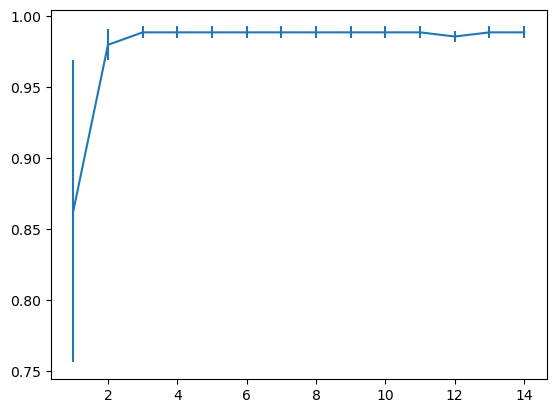

In [21]:
plt.errorbar(range(1, 1+len(rfecv.cv_results_['mean_test_score'])),
           rfecv.cv_results_['mean_test_score'],
           yerr=rfecv.cv_results_['std_test_score'])

In [22]:
rfecv.cv_results_['mean_test_score']

array([0.8625731 , 0.97953216, 0.98830409, 0.98830409, 0.98830409,
       0.98830409, 0.98830409, 0.98830409, 0.98830409, 0.98830409,
       0.98830409, 0.98538012, 0.98830409, 0.98830409])

## モデルの係数や重要度で特徴量選択

In [27]:
sfm = SelectFromModel(RandomForestClassifier(random_state=0))
X_selected = sfm.fit_transform(X, y)

In [28]:
X_selected

array([[ 18.7       , 181.        , 349.69      ,  20.4       ,
          2.09090909],
       [ 17.4       , 186.        , 302.76      ,  22.1       ,
          2.27011494],
       [ 18.        , 195.        , 324.        ,  22.3       ,
          2.23888889],
       ...,
       [ 15.7       , 222.        , 246.49      ,  34.7       ,
          3.21019108],
       [ 14.8       , 212.        , 219.04      ,  30.4       ,
          3.05405405],
       [ 16.1       , 213.        , 259.21      ,  33.8       ,
          3.09937888]])

In [29]:
sfm.estimator_.feature_importances_

array([5.37636387e-02, 9.70075338e-02, 1.60839300e-01, 5.75920737e-02,
       5.42027344e-02, 2.49688682e-02, 7.46833341e-02, 1.67119160e-01,
       2.41818437e-01, 5.98581401e-02, 3.06572915e-03, 1.57117612e-03,
       3.48306537e-03, 2.68093065e-05])

In [30]:
sfm.feature_names_in_[sfm.get_support()]

array(['culmen_depth_mm', 'flipper_length_mm',
       'culmen_length_mm * culmen_depth_mm', 'culmen_diff',
       'culmen_ratio'], dtype=object)

In [31]:
sfm.get_support()

array([False,  True,  True, False, False, False,  True,  True,  True,
       False, False, False, False, False])

## L1正則化項で特徴力選択

In [38]:
sfm = SelectFromModel(LogisticRegression(penalty="l1", solver='liblinear'))
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('feature selection', sfm)])
pipeline.set_output(transform='pandas')
pipeline.fit_transform(X, y)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,culmen_depth_mm^2,culmen_length_mm * culmen_depth_mm,culmen_diff,culmen_ratio,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,-0.884499,0.785449,-1.418347,-0.564142,-0.170197,0.768371,-1.024588,-1.036429,-0.754193,2.388699,-0.965507,1.017700
1,-0.811126,0.126188,-1.062250,-0.501703,-0.550838,0.070068,-0.751183,-0.675598,-0.754193,2.388699,1.035725,-0.982607
2,-0.664380,0.430462,-0.421277,-1.188532,-0.220261,0.386112,-0.719018,-0.738471,-0.754193,2.388699,1.035725,-0.982607
4,-1.324737,1.089724,-0.563715,-0.938776,-0.368543,1.107627,-1.507068,-1.417695,-0.754193,2.388699,1.035725,-0.982607
5,-0.847812,1.748985,-0.777373,-0.689020,0.510134,1.879435,-1.297994,-1.405186,-0.754193,2.388699,-0.965507,1.017700
...,...,...,...,...,...,...,...,...,...,...,...,...
338,0.601305,-1.750171,0.931890,0.903175,-0.903628,-1.642135,1.082241,1.690550,-0.754193,-0.418638,1.035725,-0.982607
340,0.527932,-1.445897,1.003109,0.809516,-0.707537,-1.392157,0.921415,1.343164,-0.754193,-0.418638,1.035725,-0.982607
341,1.188289,-0.735923,1.501644,1.933419,0.351353,-0.767211,1.275233,1.217248,-0.754193,-0.418638,-0.965507,1.017700
342,0.234440,-1.192335,0.789451,1.246590,-0.709967,-1.175658,0.583679,0.902865,-0.754193,-0.418638,1.035725,-0.982607


In [39]:
sfm.estimator_.coef_

array([[ 0.        ,  0.        , -0.18594239,  0.        ,  0.        ,
         0.        ,  0.07862204, -6.98527048,  0.        , -0.34233759,
         0.89038287, -0.53512157,  0.6572312 ,  0.        ],
       [ 4.11412898,  0.        ,  0.        , -2.42118559,  0.        ,
         0.25112235,  0.        ,  0.        ,  0.        ,  2.55243606,
         0.        ,  0.78436695,  0.        ,  0.        ],
       [ 0.        , -2.77497201,  1.69725364,  1.82006469,  0.        ,
         0.        ,  0.        ,  0.        ,  0.50992765, -0.2404725 ,
         0.        ,  0.        ,  0.        ,  0.        ]])

In [40]:
sfm.get_support()

array([ True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False])

In [41]:
sfm.feature_names_in_

array(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'culmen_length_mm^2', 'culmen_depth_mm^2',
       'culmen_length_mm * culmen_depth_mm', 'culmen_diff',
       'culmen_ratio', 'island_Dream', 'island_Torgersen', 'sex_FEMALE',
       'sex_MALE', 'sex_NaN'], dtype=object)